[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

# Logistic Regression

Although its name would suggest otherwise, logistic regression is a classification method.
As we go along, it may become clear why the word regression is in there.

### Classification problems

In supervised learning we use *labeled data*:

$$
\left( \;(\mathbf{x}^{(1)}, y^{(1)}),\; (\mathbf{x}^{(2)}, y^{(2)}),\ldots,(\mathbf{x}^{(n)}, y^{(n)}) \;\right)
$$

where $\mathbf{x}^{(i)}$ is a $d$ dimensional *feature vector* and $y^{(i)}$ is the label associated with $\mathbf{x}^{(i)}$.

For *classification problems* the labels are a discrete set, e.g. $\{0, 1 \}$ for a binary classification problem.
For *regression problems* the labels are continuous.

Regression is the hammer we reach for when we want to answer *how much?* or *how many?* questions.  If you want to predict the number of dollars (price)
at which a house will be sold,
or the number of wins a baseball team might have,
or the number of days that a patient
will remain hospitalized before being discharged,
then you are probably looking for a regression model.

In this section, we focus on *classification* problems
where we put aside *how much?* questions
and instead focus on *which category?* questions.

* Does this email belong in the spam folder or the inbox?
* Is this customer more likely to sign up or not to sign up for a subscription service?
* Does this image depict a donkey, a dog, a cat, or a rooster?
* Which movie are you most likely to watch next?


In the figure below we plot a toy classification dataset.

### Linear classifiers

Earlier in the course we discussed the use of a linear function as a regression function.  Here we will use the linear function 

$$
f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b
$$

as a classifier.
The class associated with $\mathbf{x}$ is decided according to the sign of the dot product captured by $f(\mathbf{x})$.  The vectors $\mathbf{x}$ such that $\mathbf{w}^\top \mathbf{x} + b=0$ form the decision boundary, which is a line in two dimensions, a plane in three dimensions, and hyperplane in higher dimensions.

For example:

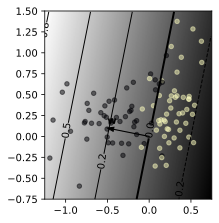

In [14]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=1, class_sep=0.3, random_state=1)
plt.style.use('default')
plt.figure(figsize=(3,5))
plt.scatter(X[:,0], X[:,1], c=1-y, alpha=0.5, s=20, cmap='magma');

w = np.array([-0.5, 0.1])
b = 0
delta = 0.01
xmin=-1.25;xmax=0.75;ymin=-0.75;ymax=1.5
xs = np.arange(xmin, xmax, delta)
ys = np.arange(ymin, ymax, delta)
x_grid, y_grid = np.meshgrid(xs, ys)

Z = w[0] * x_grid + w[1] * y_grid + b
    
im = plt.imshow(Z, origin='lower',
                cmap=plt.cm.gray, extent=(xmin,xmax,ymin,ymax) )

C = plt.contour(x_grid, y_grid, Z, 5, 
                origin='lower',
                linewidths=(1,1,2,1,1),
                colors = 'black')

plt.clabel(C, inline=1, fmt='%1.1f')

plt.arrow(0,0,w[0],w[1], width=0.001,head_width=0.05, length_includes_head=True, alpha=1,linestyle='-',color='k');
plt.text(w[0], w[1]+0.05, r"$\mathbf{w}$");


### Using probabilities to quantify prediction confidence

Using $f(\mathbf{x})$ directly as a classifier is a viable approach that is commonly taken.  However, as users of machine learning, we are interested in making *confident* predictions.
While, the magnitude of $f(\mathbf{x})$ can tell us something about our confidence in the prediction, there is no easy way for us to interpret that value as a measure of confidence.  What would help us is a way to estimate $p(y | \mathbf{x})$.

In this notebook we will focus on binary classification problems.  In this case the only two options are $p(y=1 | \mathbf{x})$, and $p(y=0 | \mathbf{x})$, which satisfy:

$$
p(y=0 | \mathbf{x}) = 1 - p(y=1 | \mathbf{x}).
$$

When given an input $\mathbf{x}$, we predict the label that maximizes $p(y | \mathbf{x})$.

We would like to learn to predict a probability $ p(y | \mathbf{x})$  for a binary classification problem using dot products.
A dot product prduces arbitrary numbers, so cannot serve to produce probabilities because they need to be between 0 and 1.
However, we can convert a dot product to a probability by applying a "squashing function" to the dot product e.g. using the so-called **logistic function**:

$$
p(y=1|\mathbf{x})= \sigma(\mathbf{w}^\top \mathbf{x})
$$

where $\sigma(s)$ is the logistic function which is defined by:

$$
\sigma(s) = \frac{1}{1 + e^{-s}}.
$$

We can now express our logistic classifier as:

$$
p(y=1|\mathbf{x})= \frac{1}{1 + e^{-\mathbf{w}^\top \mathbf{x}}}.
$$

Now we can understand the name **logistic regression**:  logistic for its use of the logistic function, and regression because it's a regression of class probabilities.

Let's take a look at the graph of the logistic function (aka the sigmoid function), which demonstrates its ability to serve as a "squashing function":

In [3]:
def sigmoid(s):
    return 1/(1+np.exp(-s))

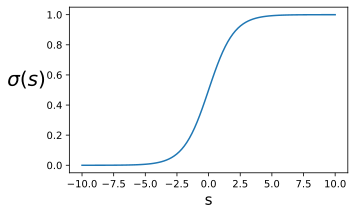

In [4]:
s = np.linspace(-10,10, 100)
plt.figure(figsize=(5,3))
plt.plot(s, sigmoid(s))
plt.xlabel("s", fontsize=15)
plt.ylabel(r"${\sigma}(s)$", rotation=0, fontsize=20, labelpad=20);

We can express the probability $p(y|\mathbf{x})$ as follows:

$$
p(y|\mathbf{x})= \begin{cases}    \sigma(\mathbf{w}^\top \mathbf{x}) & \textrm{for} \space {y}=1 \newline
1- \sigma(\mathbf{w}^\top \mathbf{x}) \space & \textrm{for} \space {y}=0
\end{cases}
$$

### Justifying the logistic function


The choice of the logistic function seems arbitrary.  The following discussion will provide some motivation.

First, let's consider the ratio

$$\frac{p(y=1|\mathbf{x})}{p(y=0|\mathbf{x})} = \frac{p(y=1|\mathbf{x})}{1- p(y=1|\mathbf{x})}.$$

In statistics this ratio is called the **odds**.

What did we gain?  Whereas $p(y=1|\mathbf{x})$ is a number between 0 and 1, the odds is a number between 0 and infinity.

That's an improvement, but again there's no natural way to model that using a dot product.  So instead, we will focus on the log odds:

$$\log \frac{p(y=1|\mathbf{x})}{p(y=0|\mathbf{x})} = \log \frac{p(y=1|\mathbf{x})}{1- p(y=1|\mathbf{x})} .$$

The log-odds is between negative infinity, and infinity and can therefore be modeled using a dot product.

Our choice to model the log-odds using a dot product gives the following:

$$\log \frac{p(y=1|\mathbf{x})}{1- p(y=1|\mathbf{x})} = \mathbf{w}^\top \mathbf{x}.$$

Solving for $p(y=1|\mathbf{x})$ we find that 

$$
p(y=1|\mathbf{x})= \frac{1}{1 + e^{-\mathbf{w}^\top \mathbf{x}}}.
$$

In conclusion, the choice to model the log-odds ratio using a dot product gave us the motivation to use the logistic function as a "squashing function" to generate a probability from a dot product.

### Exercise

Check that solving for $p(y=1|\mathbf{x})$ in
$$\log \frac{p(y=1|\mathbf{x})}{1- p(y=1|\mathbf{x})} = \mathbf{w}^\top \mathbf{x}$$ indeed gives us
$$
p(y=1|\mathbf{x})= \frac{1}{1 + e^{-\mathbf{w}^\top \mathbf{x}}}.
$$

### Exercise: Properties of the logistic function

Verify that:

$$
\sigma(s) = \frac{1}{1+e^{-s}} = \frac{e^s}{1+e^s}
$$

$$
1- \sigma(s) = \sigma(-s) = \frac{1}{1+e^{s}}
$$

$$
\sigma'(s) = \sigma(s)(1-\sigma(s))
$$

The following figure plots these functions: 

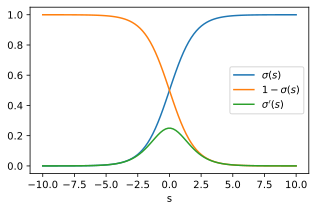

In [5]:
plt.figure(figsize=(5,3))
s = np.linspace(-10,10, 100)
plt.plot(s, sigmoid(s), label = r'$\sigma(s)$')
plt.plot(s, 1-sigmoid(s), label = r'$1-\sigma(s)$')
plt.plot(s, sigmoid(s) *(1-sigmoid(s)), label = r"$\sigma'(s)$")

plt.xlabel("s")
plt.legend();

### Is logistic regression really linear?

Given that the dot product is squashed using a non-linear function, it's not clear that the resulting classifier is indeed linear.  To answer this question, we first observe that

$$
p(y=1|\mathbf{x})=\frac{e^{\mathbf{w}^\top \mathbf{x}}}
{e^{\mathbf{w}^\top \mathbf{x}}+1} 
$$

$$
{p(y=0|\mathbf{x})}=1-{p(y=1|\mathbf{x})}=\frac{1}{1 + e^{\mathbf{w}^\top \mathbf{x}}} 
$$

To  figure  out  how  the  decision  boundary  looks  like, we consider the following equation:

$$
p(y=1|\mathbf{x})=p(y=0|\mathbf{x})
$$


Solving for $\mathbf{x}$ we get that
$
e^{\mathbf{w}^\top \mathbf{x}}=1
$
i.e. the points on the decision boundary satisfy
$
\mathbf{w}^\top \mathbf{x}=0 
$, which is the equation for a hyperplane.

Here's a plot that illustrates that:


In [6]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import LinearLocator, FormatStrFormatter
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
X = np.linspace(-10, 10, 1000)
X1, Y1 = np.meshgrid(X, X )

Z = sigmoid(X1)
surf=ax.plot_surface(X1,Y1,Z,linewidth=0, cmap=plt.get_cmap('bone'), antialiased=False)

ax.set_zlim(0, 1.01)
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

ax.set_zlabel('probability',rotation=0)
ax.view_init(azim = 180+60, elev = 40)

### Maximum likelihood: a general principle for model fitting 

Before we can train logistic regression, we need a principle that tells us *which* parameter values to prefer once we have expressed our model in the language of probabilities. That principle is **maximum likelihood**.

The idea is general and applies widely. Whenever a model assigns a
probability to data as a function of some unknown parameters, the likelihood is that probability viewed as a function of the parameters. Maximum likelihood estimation says:
**choose the parameter values that make the observed data most probable**. Or equivalently, the values under which the data we actually collected would be least surprising. It is one of the most widely used recipes in machine learning for turning data into parameter estimates, and we will use it repeatedly throughout the course.

Before applying it to logistic regression, let's build intuition with the simplest estimation problem there is: figuring out how biased a coin is.

Suppose we have a coin that lands heads with some unknown probability $\theta$.
We flip it $n$ times and record the outcomes
$y^{(1)}, \ldots, y^{(n)}$, where $y^{(i)} = 1$ for heads and $y^{(i)} = 0$ for tails.
Say we observe $k$ heads out of $n$ flips. What is our best guess for $\theta$?

Intuitively the answer is $\theta = k/n$ — the fraction of heads. Maximum likelihood makes that intuition precise and, importantly, gives us a generally applicable recipe.

**Step 1: Write down the probability of a single outcome.**
A single flip is a Bernoulli trial, so we can write its probability as

$$
p(y \mid \theta) = \theta^{y}\,(1-\theta)^{1-y}.
$$

Let's check that this does the right thing: when $y=1$ it gives $\theta$, and when $y=0$ it gives $1-\theta$. The exponents act as switches that select the correct term.

**Step 2: Write down the likelihood of the whole dataset.**
Assuming the flips are independent, the probability of the observed sequence is the product of the per-flip probabilities. This product, viewed as a function of the parameter $\theta$, is the **likelihood**:

$$
L(\theta) = \prod_{i=1}^{n} \theta^{y^{(i)}} (1-\theta)^{1-y^{(i)}}
          = \theta^{\,k}\,(1-\theta)^{\,n-k},
\qquad k = \sum_{i=1}^n y^{(i)}.
$$

**Step 3: Maximize the (log-)likelihood.**
Products of many small probabilities are awkward to differentiate and numerically tiny, so we maximize the **log-likelihood** instead. The logarithm is monotonic, so it has its maximum at the same value of $\theta$.

$$
\ell(\theta) = \log L(\theta) = k \log \theta + (n-k)\log(1-\theta).
$$

Taking the derivative and setting it to zero:

$$
\frac{d\ell}{d\theta} = \frac{k}{\theta} - \frac{n-k}{1-\theta} = 0
\quad\Longrightarrow\quad
\boxed{\;\hat{\theta} = \frac{k}{n}\;}
$$

So the maximum likelihood estimate is exactly the fraction of heads, confirming our intuition. The plot below shows the likelihood $L(\theta)$ for a sample dataset; notice that it peaks at $k/n$.


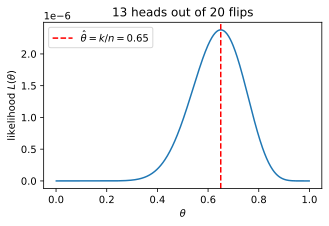

In [7]:
# Likelihood of a biased coin as a function of theta
np.random.seed(0)
n, k = 20, 13          # 20 flips, 13 heads observed
theta = np.linspace(0.001, 0.999, 500)
likelihood = theta**k * (1 - theta)**(n - k)

plt.figure(figsize=(5, 3))
plt.plot(theta, likelihood)
plt.axvline(k / n, color='r', linestyle='--', label=fr'$\hat\theta = k/n = {k/n:.2f}$')
plt.xlabel(r'$\theta$')
plt.ylabel(r'likelihood $L(\theta)$')
plt.title(f'{k} heads out of {n} flips')
plt.legend();


### Applying maximum likelihood to logistic regression

Next, we will apply the maximum likelihood technique to estimation of the parameters of a logistic regression model.
For supervised learning the outcome, i.e. $y^{(i)}$ comes with an associated feature vector $\mathbf{x}^{(i)}$, so instead of a single shared probability $\theta$ we model a **conditional** probability $p(y^{(i)} \mid \mathbf{x}^{(i)})$ that depends on the input.

We can now apply maximum likelihood to find the optimal value of the weight vector $\mathbf{w}$.
The likelihood function is the probability of the labels $y^{(1)},\ldots,y^{(n)}$ given the corresponding $\mathbf{x}^{(1)},\ldots, \mathbf{x}^{(n)}$:

\begin{equation}
p(y^{(1)},\ldots,y^{(n)} | \mathbf{x}^{(1)},\ldots, \mathbf{x}^{(n)}) = \prod_{i=1}^{n} p({y^{(i)}| \mathbf{x}^{(i)}}).
\end{equation}

This is valid because we assume that the training examples
$(\mathbf{x}^{(1)},y^{(1)}),\ldots,(\mathbf{x}^{(n)},y^{(n)})$ are independent, a standard assumption in machine learning.

Notice that the coin's likelihood $\theta^{y}(1-\theta)^{1-y}$ is just the special case of
$p(y \mid \mathbf{x})$ in which the probability of heads is the same constant for every flip.
In logistic regression we instead let that probability vary with $\mathbf{x}$ through
$\sigma(\mathbf{w}^\top \mathbf{x})$.

The likelihood function depends on the values of model parameters, and using maximum likelihood we seek to find the parameter values that maximize the likelihood function over all choices of those parameters.
Intuitively, this selects the parameter values that make the observed data most probable.

Let's define $\hat{y}^{(i)} = p(y^{(i)} = 1 | \mathbf{x}^{(i)})$.
Using this notation we can express $-\log p({y^{(i)}| \mathbf{x}^{(i)}})$ as follows:

$$
- \log p(y^{(i)}| \mathbf{x}^{(i)}) = - y^{(i)} \log \hat{y}^{(i)} - (1-y^{(i)}) \log(1- \hat{y}^{(i)})
$$

This is the same Bernoulli log-probability we used for the coin, now with the
per-example probability $\hat{y}^{(i)}$ in place of the constant $\theta$. It holds because $y^{(i)}$ is 0 or 1 for our binary classification problem.

Recall that

$$
p(y=1|\mathbf{x}) = \sigma(\mathbf{w}^\top\mathbf{x}) = \frac{1}{1 + e^{-\mathbf{w}^\top \mathbf{x}}}.
$$

And inserting the form of $p({y^{(i)}| \mathbf{x}^{(i)}})$:

$$
- \log p({y^{(i)}| \mathbf{x}^{(i)}}) = - y^{(i)} \log \left( \sigma(\mathbf{w}^\top \mathbf{x}^{(i)}) \right) - (1-y^{(i)}) \log \left(1 - \sigma(\mathbf{w}^\top \mathbf{x}^{(i)})\right)
$$



### Maximizing the likelihood

We would like to find the weight vector that maximizes the likelihood of the data, i.e. find
$$
\max_{\mathbf{w}} \prod_{i=1}^{n}p(y^{(i)}|\mathbf{x}^{(i)})
$$
This is equivalent to maximizing the log-likelihood (since the logarithm is a monotonic function): 
$$
\max_{\mathbf{w}} \log \prod_{i=1}^{n}p(y^{(i)}| \mathbf{x}^{(i)})
$$
The logarithm of a product is a sum of the logs of the terms so our objective becomes

$$
\max_{\mathbf{w}} \sum_{i=1}^{n}\log p(y^{(i)}|\mathbf{x}^{(i)})
$$

We'll replace maximization with minimization by considering

$$
\min_{\mathbf{w}} -\frac{1}{n}\sum_{i=1}^{n}\log p(y^{(i)}|\mathbf{x}^{(i)})
$$

Using the form we derived above for $p({y^{(i)}| \mathbf{x}^{(i)}})$:

$$
- \log p(y^{(i)}| \mathbf{x}^{(i)}) = - y^{(i)} \log \hat{y}^{(i)} - (1-y^{(i)}) \log(1- \hat{y}^{(i)})
$$
and its explicit form:
$$
- \log p({y^{(i)}| \mathbf{x}^{(i)}}) = - y^{(i)} \log \left( \sigma(\mathbf{w}^\top \mathbf{x}^{(i)}) \right) - (1-y^{(i)}) \log \left(1 - \sigma(\mathbf{w}^\top \mathbf{x}^{(i)})\right)
$$

our objective now becomes:

$$
\min_{\mathbf{w}} \frac{1}{n}\sum_{i=1}^{n} \left[- y^{(i)} \log \hat{y}^{(i)} - (1-y^{(i)}) \log(1- \hat{y}^{(i)}) \right]
$$


$$
\min_{\mathbf{w}} \frac{1}{n}\sum_{i=1}^{n} \left[ - y^{(i)} \log \left( \sigma(\mathbf{w}^\top \mathbf{x}^{(i)}) \right) - (1-y^{(i)}) \log \left(1 - \sigma(\mathbf{w}^\top \mathbf{x}^{(i)})\right) \right]
$$

Therefore it is natural to interpret the function

$$
\ell^{CE}(y,\hat{y}) = - y \log \hat{y} - (1-y) \log \left(1 - \hat{y}\right) 
$$

as a loss function.  Let's take a closer look at it and see that it indeed satisfies our desiderata from a loss function.
Let's consider the case $y = 1$.  In that case, only the first term is nonzero.  When the predicted probability is equal to 1, which is what we would like, it is equal to 0, and the further away from the desired value it is, the larger the value.  A similar observation occurs for $y=0$:  In this case only the second term contributes, and this term equals to 0 when the predicted probability is equal to 0, which is the desired value for negative examples. 

The above function is known as the **cross entropy loss** or **log loss**. 
It indeed quantifies  the discrepancy of the predicted probability from the desired label.  The following plot further demonstrates that:


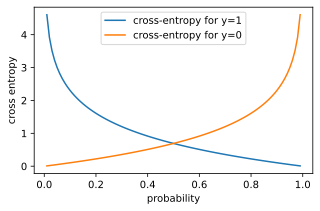

In [8]:
def cross_entropy(p, y):
    return -(y*np.log(p)+(1-y)*np.log(1-p))

plt.figure(figsize=(5,3))
p = np.linspace(0.01, 0.99, 100)
plt.plot(p, cross_entropy(p, 1), label='cross-entropy for y=1')
plt.plot(p, cross_entropy(p, 0), label='cross-entropy for y=0')

plt.xlabel('probability')
plt.ylabel('cross entropy')
plt.legend();

### Logistic regression loss

We have finally arrived at the final form of the loss function for logistic regression:

$$
L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n} \left[ - y^{(i)} \log \left( \sigma(\mathbf{w}^\top \mathbf{x}^{(i)}) \right) - (1-y^{(i)}) \log \left(1 - \sigma(\mathbf{w}^\top \mathbf{x}^{(i)})\right) \right]
$$

Unlike the case of linear regression where there is a closed-form solution, there is no such solution for the logistic regression loss function.  It turns out that the loss function is convex, and therefore there is a global minimum.  Gradient descent is therefore a reasonable approach.

The gradient of our loss function is:
$$
\partial_{\mathbf{w}} L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n} \left(\sigma(\mathbf{w}^\top \mathbf{x}^{(i)}) - y^{(i)}\right) \mathbf{x}^{(i)}
$$


### Gradient descent 

**Input:** A labeled dataset; learning rate $\eta$

1. initialize $\mathbf{w}(0)$
2. for t = 0, 1, 2,... do
3. $\;\;\;\;\;\;$       compute the gradient: $\mathbf{g}_t$ = $\nabla  L(\mathbf{w}(t))$
4. $\;\;\;\;\;\;$       update the weights: $\mathbf{w}(t + 1) = \mathbf{w}(t) - \eta \mathbf{g}_t$
5. $\;\;\;\;\;\;$       if it is time to stop, break from loop.
6. end for
7. return the final weights.

The halting condition can be a specific number of iterations, or that the loss function appears to have converged, i.e. shows little change across epochs.

### Implementation

Let's implement our gradient descent logistic regression algorithm as a Python class.  This class uses an API that matches the classifier API of scikit-learn.

In [9]:
class logistic_regression:
    def __init__(self, lr=0.01, epochs=350):
        self.lr = lr
        self.epochs = epochs

    def decision_function(self, X):
        return 1/(1+np.exp(-np.dot(X, self.w)))

    def gradient(self, X, y): 
        return (self.decision_function(X) - y)@X/len(X)
  
    def loss(self, X, y):
        pred = self.decision_function(X) 
        loss_values = - y * np.log(pred) - (1 - y) * np.log(1 - pred)
        return np.mean(loss_values) 
  
    def fit(self, X, y): 
        self.w = np.zeros(X.shape[1])
        # save a history of loss values
        self.loss_history = [self.loss(X, y)]
        for epoch in range(self.epochs):
            self.w = self.w - self.lr * self.gradient(X, y)
            self.loss_history.append(self.loss(X, y))
         
    def predict(self, X): 
        pred = np.where(self.decision_function(X) >= .5, 1, 0) 
        return np.squeeze(pred) 


In [10]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=100, n_features=2, n_informative=2, 
                          n_redundant=0, n_repeated=0, n_classes=2, 
                          n_clusters_per_class=1, class_sep=0.3, 
                          random_state=1)
lr=logistic_regression(0.01, 10000)
lr.fit(X, y)
y_pred=lr.predict(X)
print('accuracy: ', np.sum(y_pred == y)/len(y))

accuracy:  0.9


Let's plot the resulting decision boundary and weight vector:

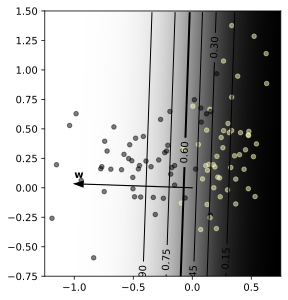

In [11]:
plt.style.use('default')
plt.scatter(X[:,0], X[:,1], c=1-y, alpha=0.5, s=20, cmap='magma');

w = lr.w/np.linalg.norm(lr.w)

delta = 0.01
xmin=-1.25;xmax=0.75;ymin=-0.75;ymax=1.5
xs = np.arange(xmin, xmax, delta)
ys = np.arange(ymin, ymax, delta)
x_grid, y_grid = np.meshgrid(xs, ys)

Z = sigmoid(lr.w[0]*x_grid + lr.w[1]*y_grid)

im = plt.imshow(Z, origin='lower',
                cmap=plt.cm.gray, extent=(xmin,xmax,ymin,ymax) )

C = plt.contour(x_grid, y_grid, Z, 7, 
                origin='lower',
                linewidths=(1,1,1,1,2,1,1),
                colors = 'black')

plt.clabel(C, inline=1, fmt='%1.2f')

plt.arrow(0,0, w[0],w[1], width=0.001,head_width=0.05, length_includes_head=True, alpha=1,linestyle='-',color='k');
plt.text(w[0], w[1]+0.05, r"$\mathbf{w}$");


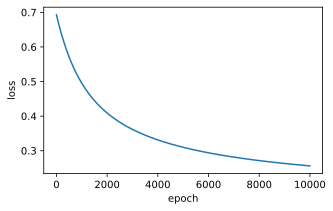

In [12]:
plt.figure(figsize=(5,3))
plt.plot(lr.loss_history)
plt.ylabel('loss')
plt.xlabel('epoch');

Make sure to train the algorithm for a sufficiently large number of epochs so that the loss has a chance to converge.

### Comments:

1. In practice logistic regression is solved by faster methods than gradient descent 

2. There is an extension to multi-class classification 

### Pros and Cons of logistic regression

#### Pros

- Fast training and prediction
- Easy to use: no tuning required
- Outputs probability estimates, and tends to be reasonably well-calibrated when the log-odds-linear assumption roughly holds
- Interpretable classifier (weights provide information about relative contribution of features)

#### Cons

- Linear classifier
- Performance is often not competitive with the best supervised learning methods

**Note:**  Use Softmax regression (aka multinomial logistic regression) when you have data with multiple classes.  This will be covered next.
